In [1]:
import os
import sys
from os.path import join
import copy

# Add parent directory (arch/) to path so we can import sibling modules
# Handle both cases: notebook run from diagnostics/ or from arch/
current_dir = os.getcwd()
if 'diagnostics' in current_dir:
    arch_dir = os.path.dirname(current_dir)
else:
    arch_dir = current_dir

if arch_dir not in sys.path:
    sys.path.insert(0, arch_dir)
    
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Subset
import pyxis.torch as pxt

from train import (
    load_model,
    evaluate_conditional_2d,
)
import config

stem = 'CNN-CNN-flow'
data_dir = '/ocean/projects/phy250048p/shared/datasets/valid_1m'
samp_dir = '/ocean/projects/phy250048p/shared/samples/samples_valid_1m.csv'
fig_dir = '/ocean/projects/phy250048p/shared/figures/'
model_dir = f'/ocean/projects/phy250048p/shared/models/{stem}/'
loss_dir = '/ocean/projects/phy250048p/shared/models/losses/'
results_dir = '/ocean/projects/phy250048p/shared/results/'
cache_dir = '/ocean/projects/phy250048p/shared/cache/'

In [2]:
plt.rcParams.update({"text.usetex": False, "font.family": "serif", "figure.dpi": 300})
os.makedirs(join(fig_dir, stem), exist_ok=True)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
model_file = join(model_dir, f'{stem}199')
model = load_model(mode=1, path=model_file,strict=True, assign=True, device=device)

In [5]:
# Get data loader
bs = 1
test_args = list(config.test.values())
test_ds = pxt.TorchDataset(data_dir)
test_dl = DataLoader(test_ds,
                     batch_size=bs,
                     pin_memory=False,
                     shuffle=False,)
nsub = 1000
subset = Subset(test_ds, np.arange(0, nsub))
sub_dl = DataLoader(subset,
                    batch_size=bs,
                    pin_memory=False,
                    shuffle=False,)

In [6]:
probs, g1_vals, g2_vals, snrs = evaluate_conditional_2d(model, subset, device=device)

In [7]:
print(probs.shape)

(1000, 200, 200)


In [8]:
# Find index with highest prob and extract map estimate
map_idx_g1, map_idx_g2 = np.unravel_index(np.array([np.argmax(probs[i]) for i in range(len(subset))]), probs[0].shape)
map_estimates = np.array([np.array([g1_vals[map_idx_g1[i]], g2_vals[map_idx_g2[i]]]) for i in range(len(subset))])/10
true_values = np.array([subset[i]['fid_pars'][:2] for i in range(len(subset))])/10

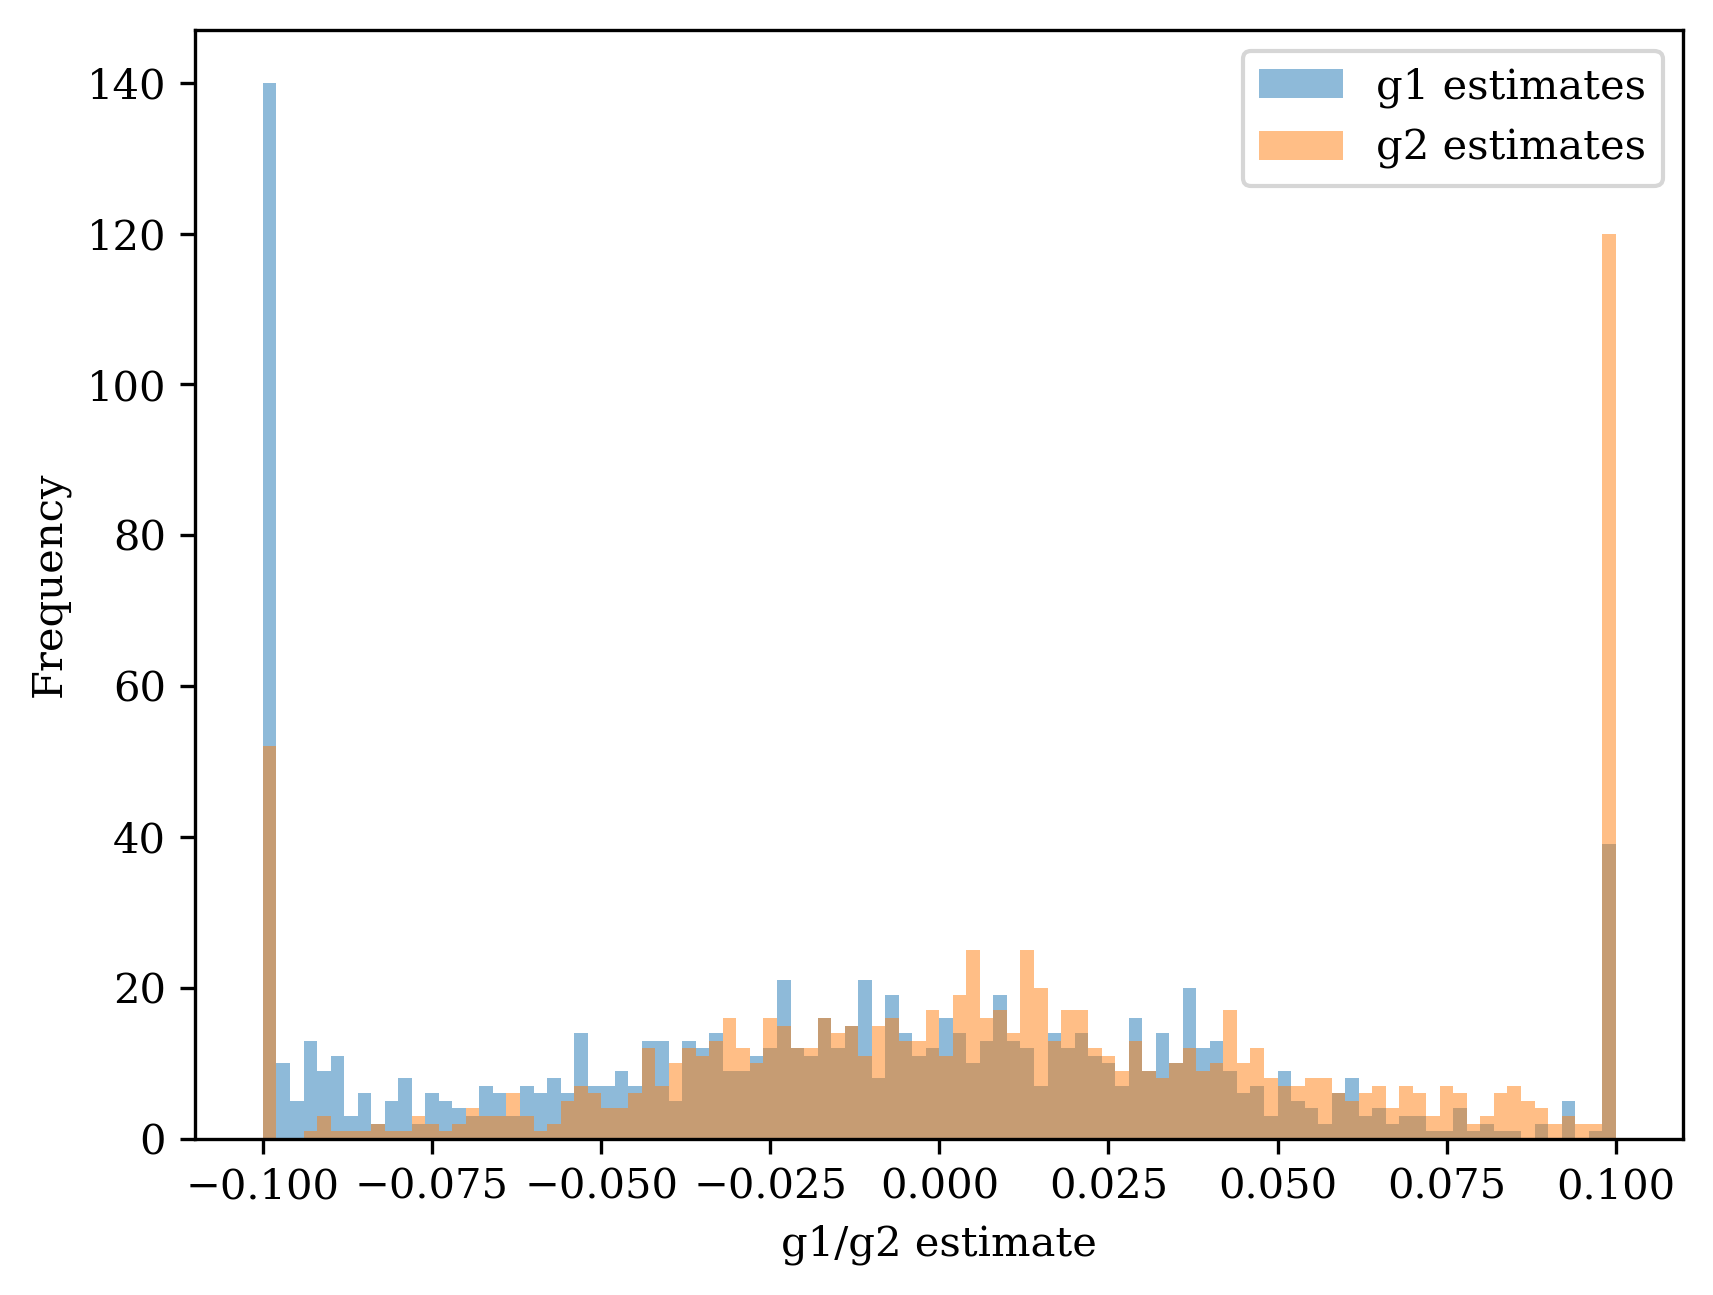

In [19]:
plt.hist(map_estimates[:, 0], bins=100, alpha=0.5, label='g1 estimates')
plt.hist(map_estimates[:, 1], bins=100, alpha=0.5, label='g2 estimates')
plt.xlabel('g1/g2 estimate')
plt.ylabel('Frequency')
plt.legend()
plt.savefig(join(fig_dir, stem, 'conditional_estimate_hist.png'))
plt.show()

In [28]:
mask = (np.max(map_estimates, axis=1) >= 0.1) | (np.min(map_estimates, axis=1) <= -0.1)

In [30]:
diff = map_estimates[~mask] - true_values[~mask]

In [31]:
print(f'g1 bias: {np.mean(diff[:, 0]):.6f} +/- {np.std(diff[:, 0])/np.sqrt(len(diff[:, 0])):.6f}')
print(f'g2 bias: {np.mean(diff[:, 1]):.6f} +/- {np.std(diff[:, 1])/np.sqrt(len(diff[:, 1])):.6f}')

g1 bias: -0.009319 +/- 0.001450
g2 bias: 0.006580 +/- 0.001569


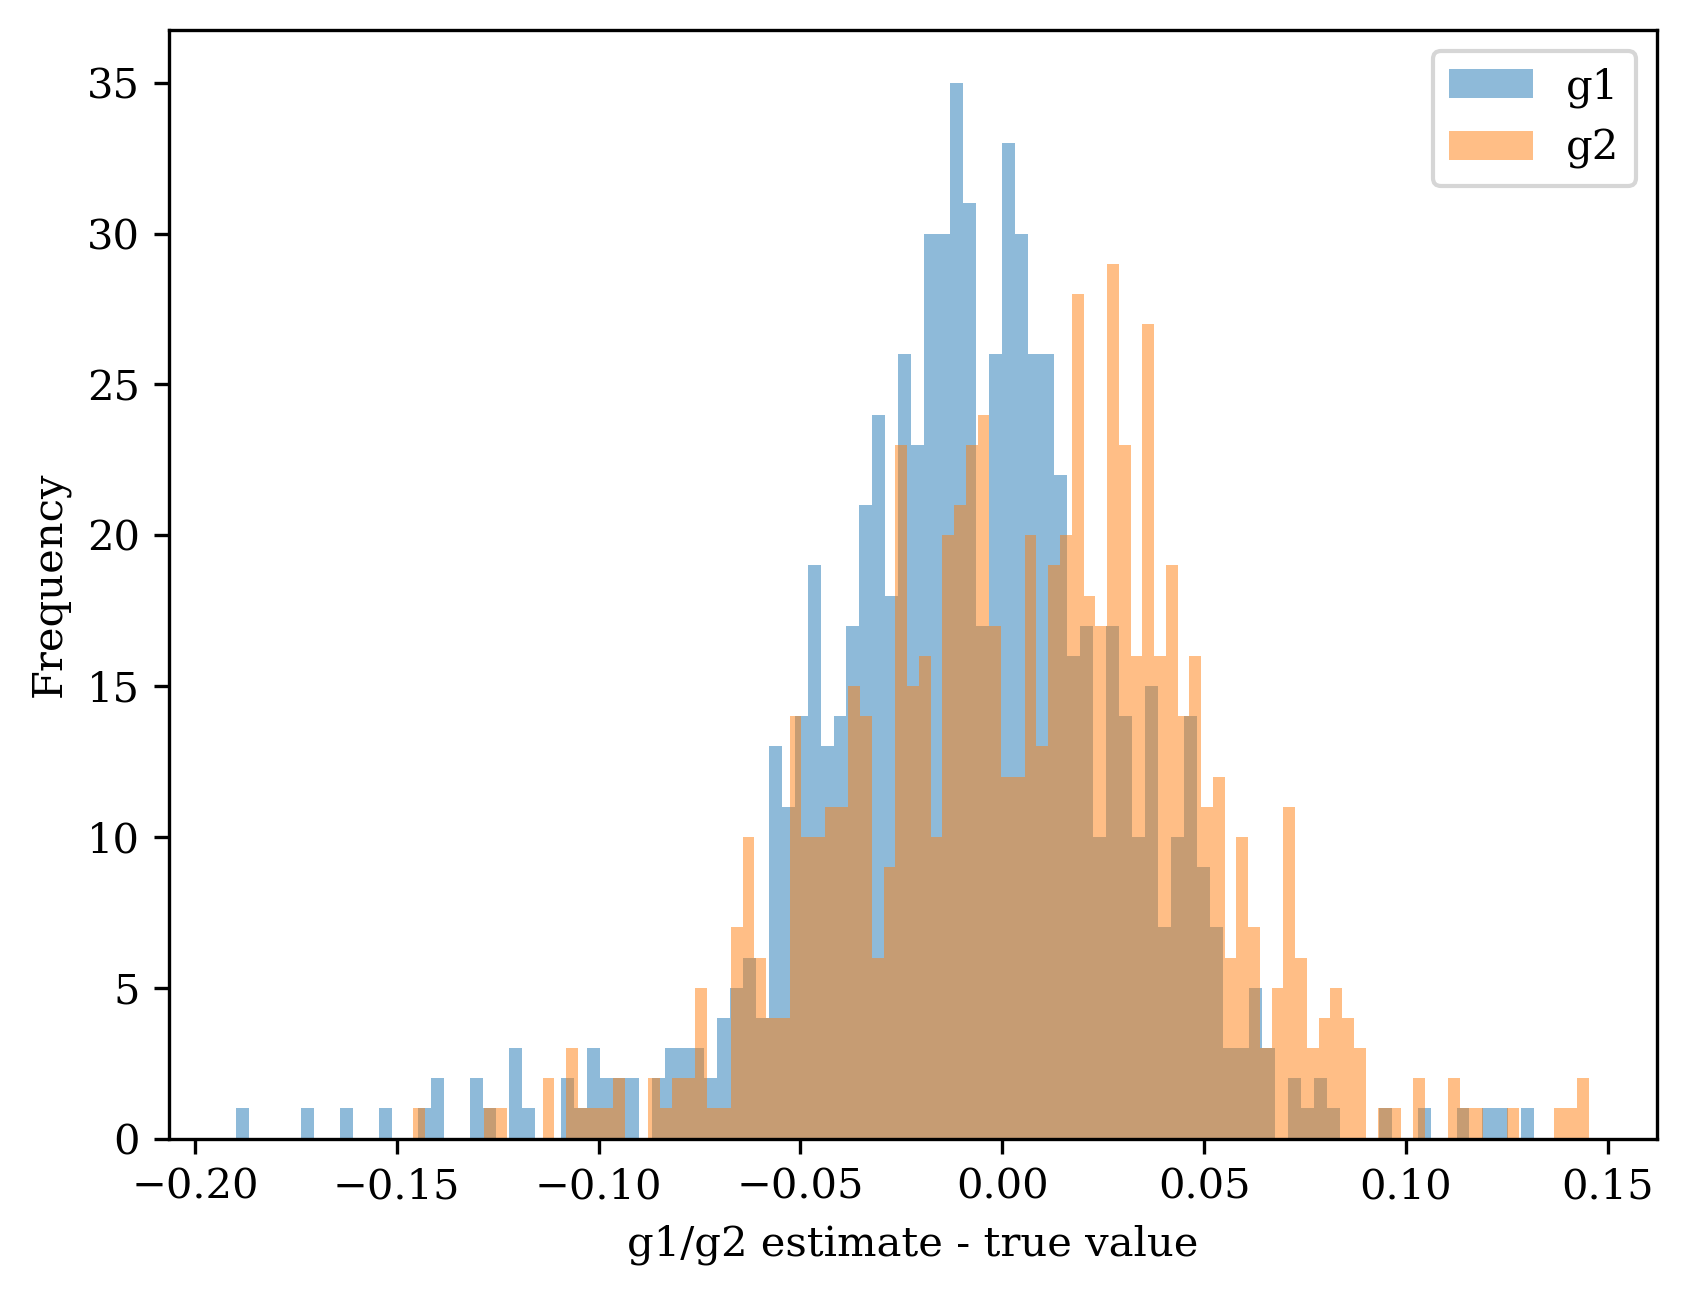

In [32]:
plt.hist(diff[:, 0], bins=100, alpha=0.5, label='g1')
plt.hist(diff[:, 1], bins=100, alpha=0.5, label='g2')
plt.xlabel('g1/g2 estimate - true value')
plt.ylabel('Frequency')
plt.legend()
plt.savefig(join(fig_dir, stem, 'conditional_estimate_diff_hist_remove_clipped.png'))
plt.show()

In [20]:
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(x, y, indexing='ij')
print(X.flatten()[:10], Y.flatten()[:10])

[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1.] [-1.         -0.97979798 -0.95959596 -0.93939394 -0.91919192 -0.8989899
 -0.87878788 -0.85858586 -0.83838384 -0.81818182]


In [7]:
log_probs = np.log(probs + 1e-10)  # Add small value to avoid log(0)

In [8]:
hi_snr = np.where(snrs > 900)[0]

Text(0.5, 1.0, 'Conditional Log Probability')

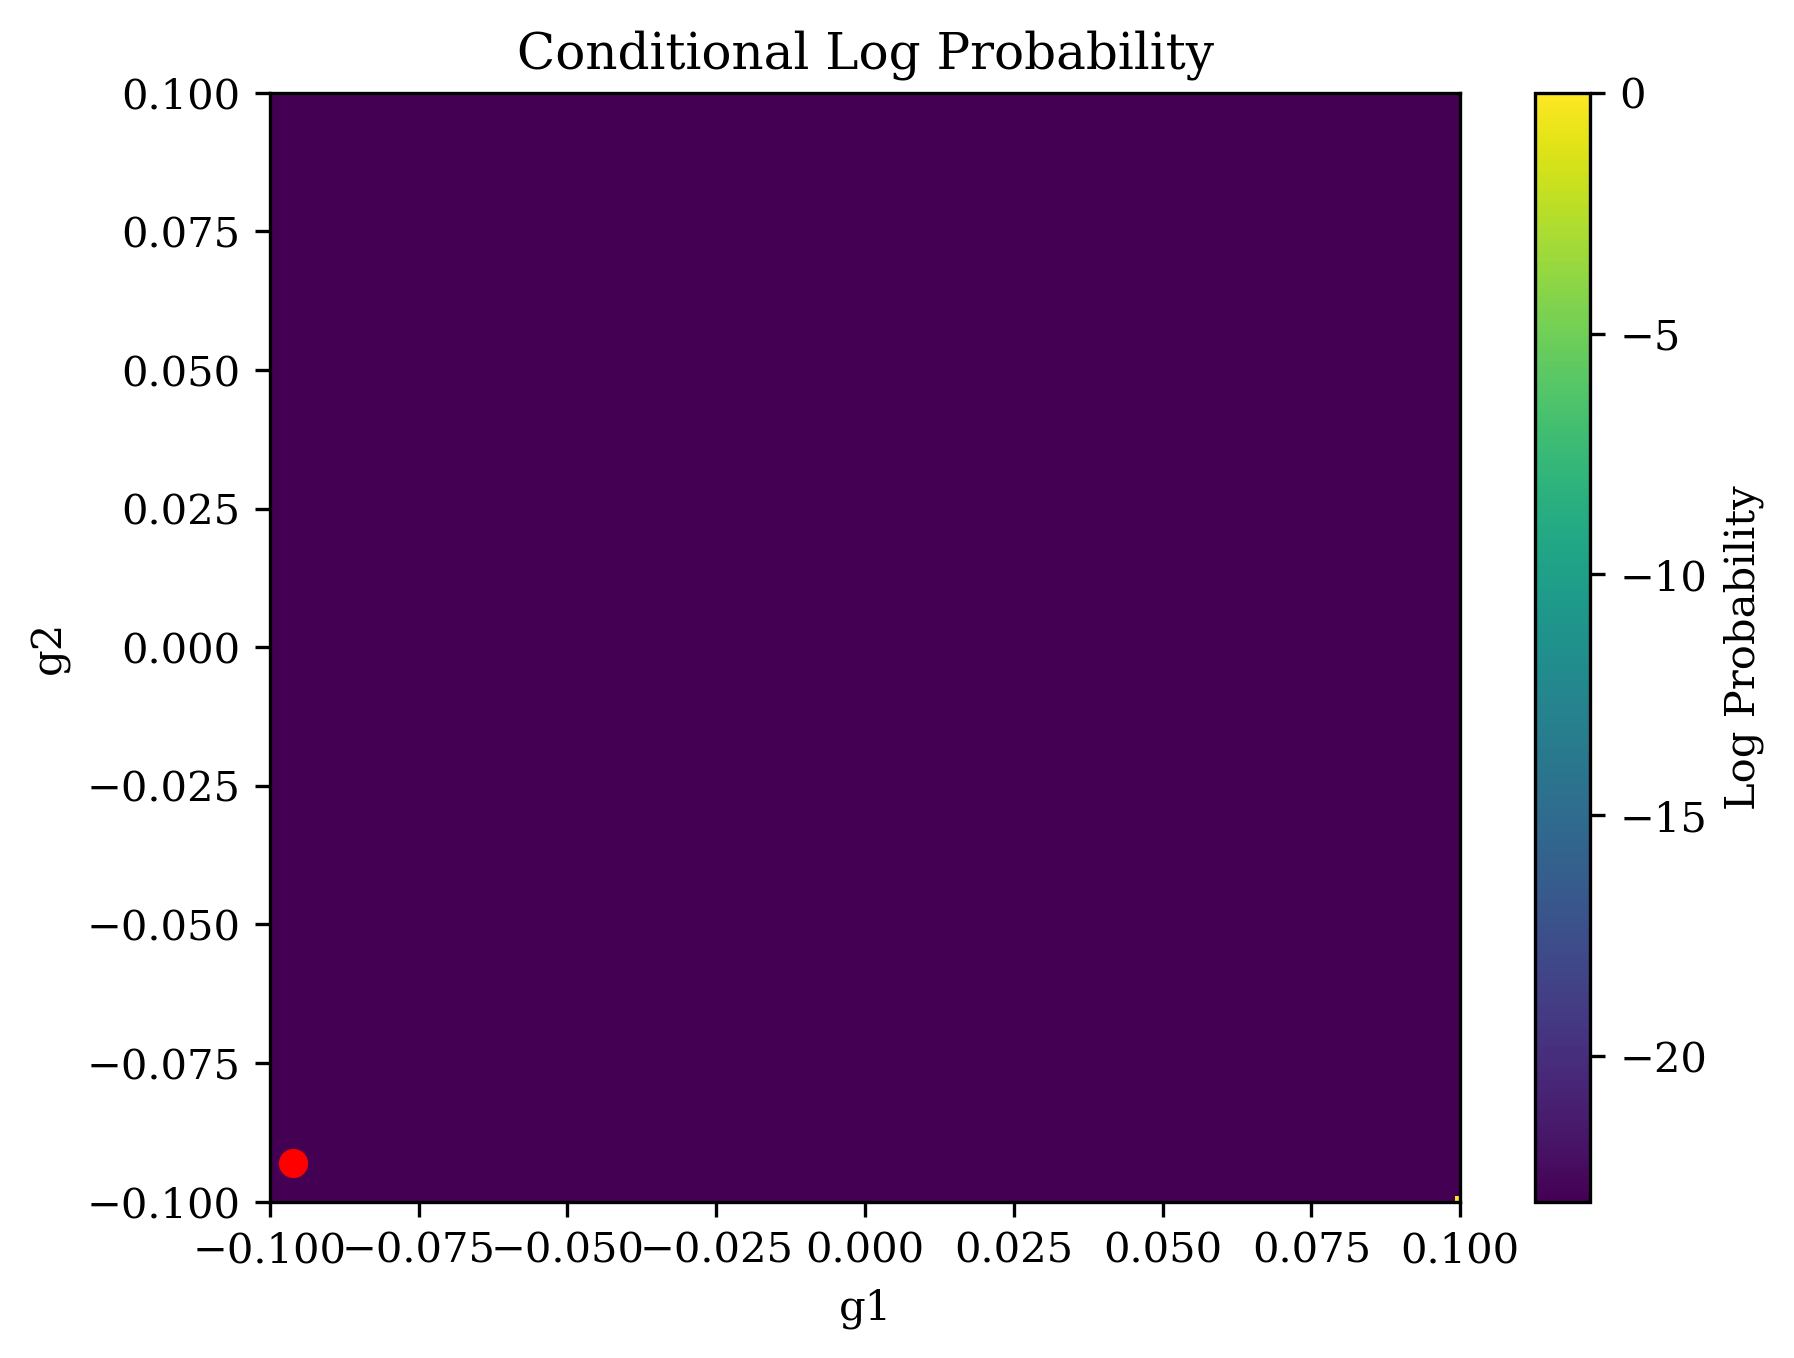

In [14]:
idx = hi_snr[3]
plt.imshow(log_probs[idx], origin='lower', aspect='auto',
           extent=(g1_vals.min()/10, g1_vals.max()/10, g2_vals.min()/10, g2_vals.max()/10),
           norm=colors.Normalize(vmin=log_probs.min(), vmax=log_probs.max()))
plt.plot(test_ds[idx]['fid_pars'][0]/10, test_ds[idx]['fid_pars'][1]/10, 'ro', label='True Values')
plt.colorbar(label='Log Probability')
plt.xlabel('g1')
plt.ylabel('g2')
plt.title('Conditional Log Probability')